# Task 1:Web Scraping
Here I will scrape 200 shows from the target website to the file SenZhang_2253761.csv. The following codes will implement this function.

After checking the data source, I found that there were not all the data I needed at once in this webpage. I have decided to first obtain the URLs of all shows on this webpage, and then access these URLs separately to obtain data.
Following two cells will prepare the libraries for the whole assignment and some functions will be used in the Task 1.

In [1]:
from IPython.display import HTML
import numpy as np
import urllib.request
import bs4
from bs4 import BeautifulSoup
import requests
from pandas import Series
import pandas as pd
from pandas import DataFrame

import matplotlib
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_context("talk")
sns.set_style("white")

import re

In [2]:
# This function can get and parse the specific url
# It will be called by the next method
def getAndParseURL(url):
    result = requests.get(url)
    soup = BeautifulSoup(result.text, "html.parser")
    return(soup)

url = "https://www.tvmaze.com/shows"

# This function can get shows' URLs but only for one page
# So it cannot solve our needs, but it can be called by the next method to solve our needs
def getShowsURLs(url):
    soup = getAndParseURL(url)
    external_links = []
    titles = soup.find_all("span", class_="title")
    for title in titles:
        a_tag = title.find('a')
        if a_tag:
            href = a_tag.get('href')
            external_links.append("https://www.tvmaze.com" + href)
    return external_links

# This function can get more than a specified number of shows URLs
# It calculates how many times should the getShowsURLs will be called and call the method
def getCountedShowsURLs(url, max_elements):
    soup = getAndParseURL(url)
    external_links = []
    titles = soup.find_all("span", class_="title")
    for title in titles:
        a_tag = title.find('a')
        if a_tag:
            href = a_tag.get('href')
            external_links.append("https://www.tvmaze.com" + href)
    if len(external_links) < max_elements:
        left_elements = max_elements - len(external_links)
        times_needed = 0
        while left_elements > 0:
            times_needed += 1
            left_elements -= len(external_links)
    for i in range(times_needed):
        tempurl = url + "?page=" + str(i+2)
        external_links.extend(getShowsURLs(tempurl))
    return external_links

Then I call the previous method to get all the URLs for the shows.

In [3]:
showsURLs = getCountedShowsURLs(url, 200)

Access these URLs separately to obtain all the data.

In [4]:
titles = []
first_air_dates = []
end_dates = []
ratings = []
genres = []
statuses = []
networks = []
summaries = []

for showURL in showsURLs:
    show = getAndParseURL(showURL)

    # scrape the title
    title_tag = show.find('title')
    if title_tag:
        full_title = title_tag.text.strip()
        clean_title = full_title.replace(" | TVmaze", "").strip()
        titles.append(clean_title)
    else:
        titles.append("")

    # scrape the start_date and end_date
    year_span = show.find('span', id='year')
    text = year_span.text.strip()
    m = re.search(r'\((\d{4})\s*-\s*(\d{4}|now)\)', text)
    if m:
        start_date, end_date = m.group(1), m.group(2)
        first_air_dates.append(start_date)
        end_dates.append(end_date)
    else:
        first_air_dates.append("")
        end_dates.append("")

    # scrape the rating
    rating_tag = show.find('b', itemprop='ratingValue')
    if rating_tag:
        rating = rating_tag.text
        ratings.append(rating)
    else:
        ratings.append("")

    # scrape the genres
    strong = show.find('strong', string='Genres:')
    if strong:
        for span in strong.find_next_siblings('span'):
            text = span.get_text(strip=True).strip("")
        if text:
            processed_text = re.sub(r'(?<!^)(?=[A-Z])(?!(F)(?=i))', ', ', text)
            genres.append(processed_text)
        else:
            genres.append("")
    else:
        genres.append("")

    # scrape the status
    strong = show.find('strong', string='Status:')
    if strong:
        full_text = strong.parent.get_text(strip=True)
        status_info = full_text.replace('Status:', '').strip()
        status_info = status_info.replace('returning', 'returning ')
        statuses.append(status_info) 
    else:
        statuses.append("") 

    # scrape the network
    strong = show.find('strong', string='Web channel: ')
    if strong:   
        a_tag = strong.next_sibling.next_sibling
        if a_tag:
            network = a_tag.text.strip()
            networks.append(network)
        else:
            networks.append("")  
    else:
        networks.append("")  

    # scrape the summary
    meta_desc = show.find('meta', property='og:description')
    if meta_desc and meta_desc.get('content'):
        summary = meta_desc['content'].strip()
        summaries.append(summary)
    else:
        summaries.append("")

Integrate them into a table.

In [5]:
scraped_data = pd.DataFrame({'Title': titles, 'First_air_date': first_air_dates, 'End_date': end_dates, "Rating": ratings, "Genre": genres, "Status": statuses, "Network": networks, "Summary": summaries})

In [6]:
scraped_data

,Title,First_air_date,End_date,Rating,Genre,Status,Network,Summary
0,The Witcher,2019,now,8,"Drama, Action, Fantasy",Running; returning October 2025,Netflix,"Based on the best-selling fantasy series, The ..."
1,Stranger Things,2016,now,8.5,"Drama, Horror, Science-Fiction",Running; returning November 2025,Netflix,"When a young boy vanishes, a small town uncove..."
2,NCIS,2003,now,7.9,"Drama, Action, Crime",Running,,NCIS (Naval Criminal Investigative Service) is...
3,South Park,1997,now,8.3,Comedy,Running,,South Park is an adult comedy animation show c...
4,Grey's Anatomy,2005,now,7.7,"Drama, Romance, Medical",Running,,The doctors of Grey Sloan Memorial Hospital de...
...,...,...,...,...,...,...,...,...
195,Chief of War,2025,now,6.8,"Drama, History",To Be Determined,Apple TV,Chief of War follows the epic and unprecedente...
196,The Blacklist,2013,2023,8.1,"Drama, Crime, Thriller",Ended,,The Blacklist is a crime drama involving a for...
197,Untamed,2025,now,7.1,"Crime, Thriller, Mystery",Running; returning 2026,Netflix,"Untamed follows Kyle Turner, a special agent f..."
198,A Man on the Inside,2024,now,7.3,"Comedy, Espionage",Running; returning November 2025,Netflix,A retired man gets a new lease on life when he...


Save the table to CSV file.

In [7]:
scraped_data.to_csv('SenZhang_2253761.csv', index=False, encoding='utf-8')

# Task 2:Data analysis
When we first open the website, we will wonder why the shows are arranged in this way. Is it in order of name? Absolutely not. The first title is The Witcher,but Alien:Earth is after it. It may relate to the popularity, which is a comprehensive score related to the duration, end time and rating. Here is the first hypothesis. We can also notice that everyone seems to prefer watching drama. So the second hypothesis is that the drama is the most popular. In addition, we have heard a lot of news about the increasing popularity of Netflix. Therefore, we assume that Netflix has the largest market share.

## 2.1:Data processing
First,we need to check the datatypes of the columns for subsequent operations.

In [8]:
scraped_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Title           200 non-null    object
 1   First_air_date  200 non-null    object
 2   End_date        200 non-null    object
 3   Rating          200 non-null    object
 4   Genre           200 non-null    object
 5   Status          200 non-null    object
 6   Network         200 non-null    object
 7   Summary         200 non-null    object
dtypes: object(8)
memory usage: 12.6+ KB


Our first hypothesis is that the shows are sorted by a comprehensive score related to the duration, end time and rating. So these data should be converted to numeric.

In [9]:
scraped_data['Rating'] = pd.to_numeric(scraped_data['Rating'], errors='coerce')

scraped_data['First_air_date'] = pd.to_numeric(
    scraped_data['First_air_date'], errors='coerce'
)

scraped_data['End_date'] = scraped_data['End_date'].replace('now', str(2025))
scraped_data['End_date'] = pd.to_numeric(scraped_data['End_date'], errors='coerce')

In [10]:
scraped_data['Show_duration'] = scraped_data['End_date'] - scraped_data['First_air_date']

Our second hypothesis is that the most popular genre is the drama. We need count the frequency of occurrence for each genre.

In [11]:
genre_counts = scraped_data['Genre'].str.split(', ').explode().value_counts()

Third hypothesis is that Netflix has the largest market share. There are many null values in this column, so we need to add the traditional television platform to these values. After that, we can count all the appearance of these values.

In [12]:
scraped_data['Network_processed'] = scraped_data['Network'].apply(
    lambda x: 'Traditional TV' if x == '' or pd.isna(x) else x
)
network_counts = scraped_data['Network_processed'].value_counts()

## 2.2:First hypothesis
If our hypothesis is true, these shows must have high ratings. Those with low ratings should not be included in our data. Therefore, we can make a Boxplot now to see the overall rating situation.

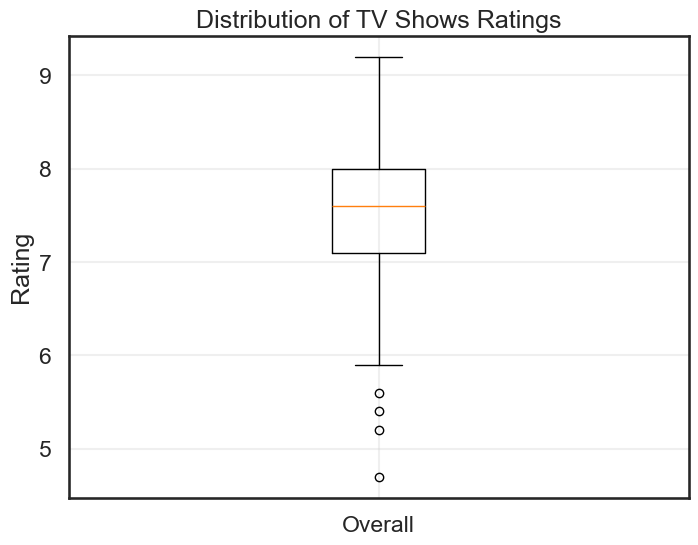

In [13]:
plt.figure(figsize=(8, 6))
plt.boxplot(scraped_data['Rating'].dropna(), tick_labels=['Overall'])
plt.title('Distribution of TV Shows Ratings')
plt.ylabel('Rating')
plt.grid(True, alpha=0.3)
plt.show()

The overall rating seems to be an excellent score, which is consistent with our hypothesis. We can also separate the data into two parts to check the result. The first 100 data should be higher than the last 100 data.

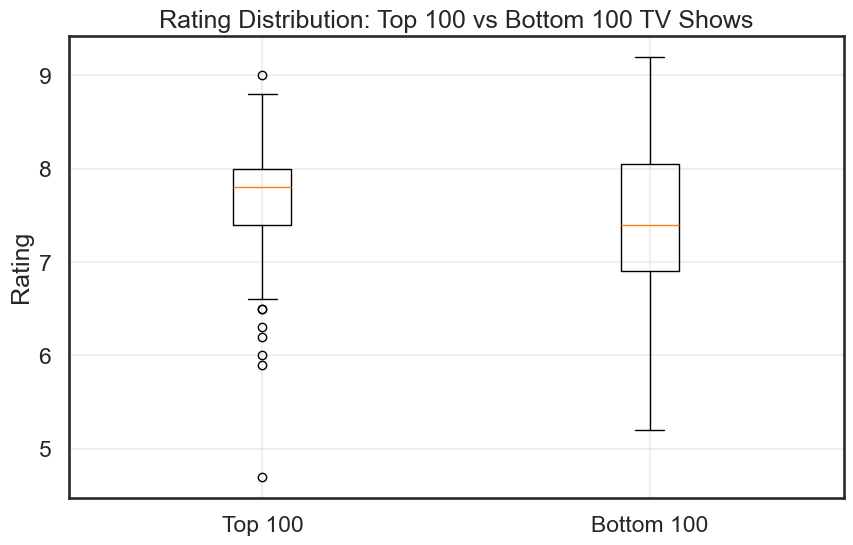

In [14]:
plt.figure(figsize=(10, 6))

top_100 = scraped_data.head(100)['Rating'].dropna()
bottom_100 = scraped_data.tail(100)['Rating'].dropna()

plt.boxplot([top_100, bottom_100], 
            tick_labels=['Top 100', 'Bottom 100'])

plt.title('Rating Distribution: Top 100 vs Bottom 100 TV Shows')
plt.ylabel('Rating')
plt.grid(True, alpha=0.3)
plt.show()

The result also proves that first 100 ratings are higher than the last 100 ratings. But the ranking here is not simply based on rating, so we also assume it is related to duration and end time.

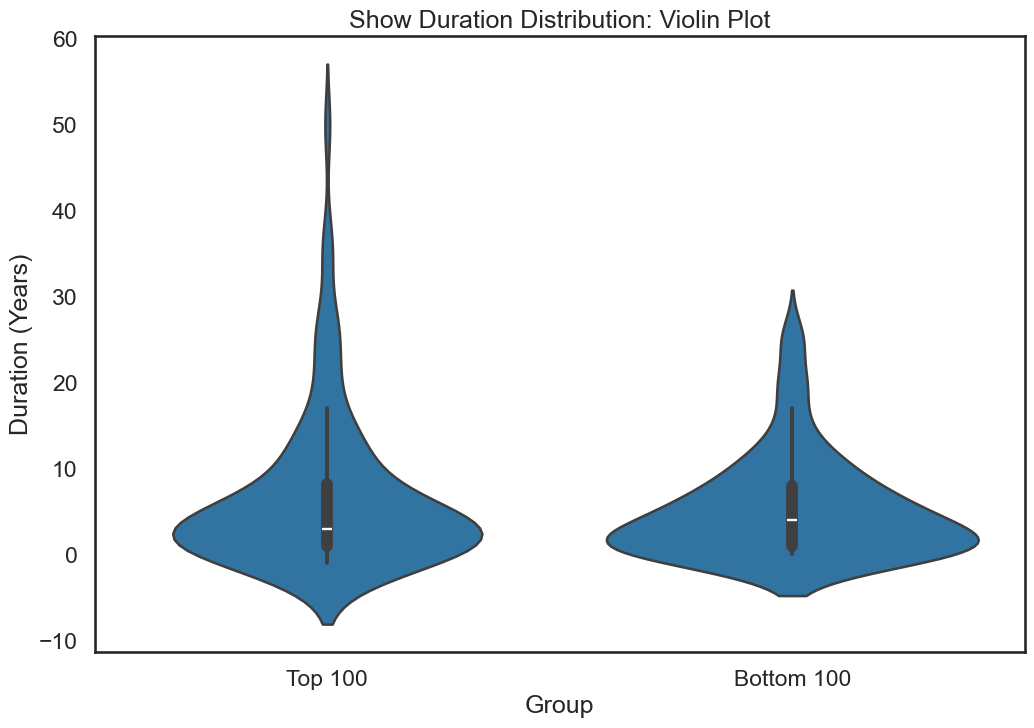

In [15]:
top_100_duration = scraped_data.head(100)['Show_duration'].dropna()
bottom_100_duration = scraped_data.tail(100)['Show_duration'].dropna()
duration_data = pd.DataFrame({
    'Duration': pd.concat([top_100_duration, bottom_100_duration]),
    'Group': ['Top 100'] * len(top_100_duration) + ['Bottom 100'] * len(bottom_100_duration)
})

plt.figure(figsize=(12, 8))
sns.violinplot(data=duration_data, x='Group', y='Duration', inner='box')
plt.title('Show Duration Distribution: Violin Plot')
plt.ylabel('Duration (Years)')
plt.show()

While both groups have similar median durations, the top 100 shows include significantly more long-running series, as evidenced by the extended upper tail in their duration distribution. It also supports our first hypothesis.

Therefore, we can assume that popularity has the following formula.
\begin{equation}
P = \alpha R + \beta D E
\end{equation}
where $P$ denotes the popularity score, $R$ is the rating, $D$ represents the show duration, $E$ is the end year, and $\alpha$, $\beta$ are weighting coefficients.

To further support our hypothesis, we need to prove the validity of this formula. However, we need to do the standardization to the end year values, beacuse the large value will dominate the formula. After that, we calculate the popularity score for every show. The higher score the show get, it will has smaller ranking index. We can compare the correlation between the ranking index obtained here and the original index. The higher the correlation, the more accurate the formula will be.

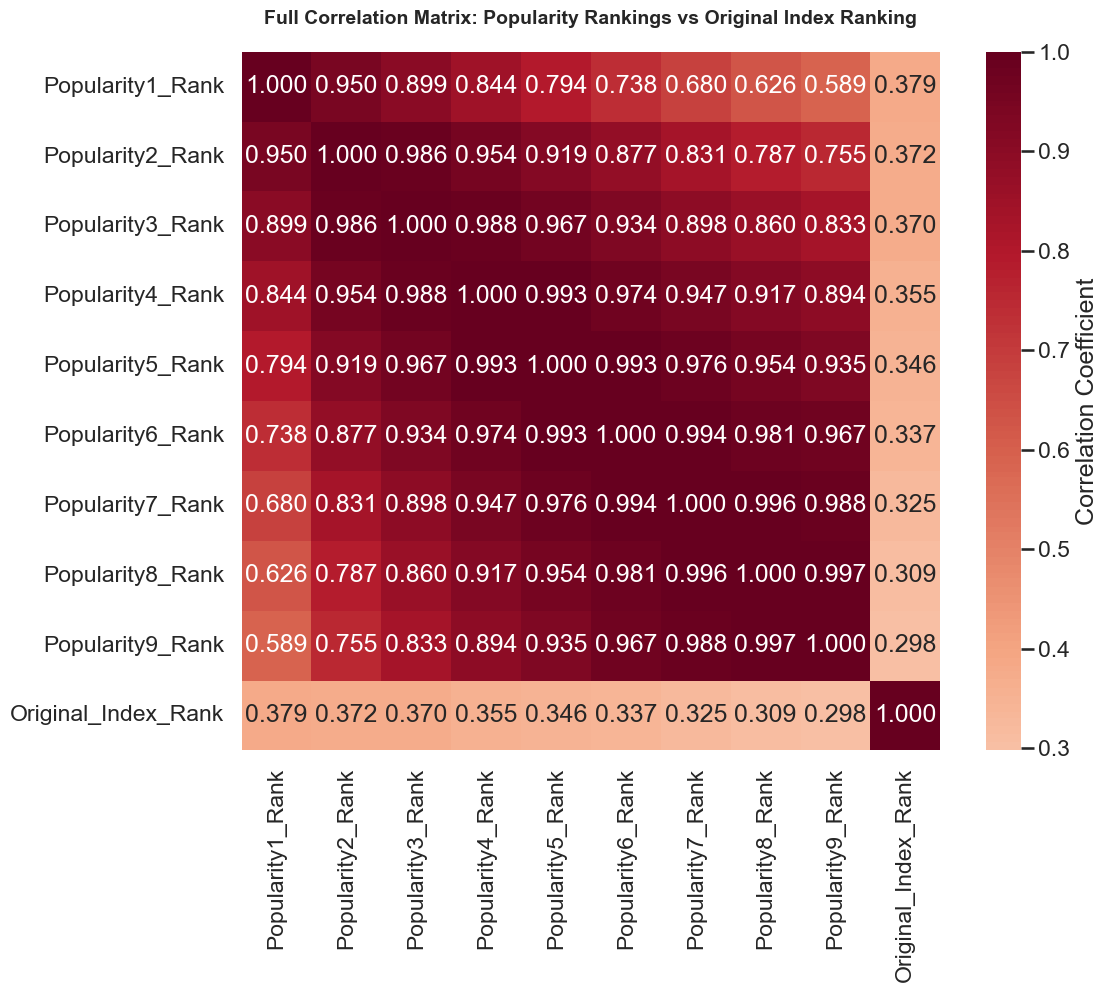

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scraped_data['EndTime_std'] = scaler.fit_transform(scraped_data[['End_date']])

coefficient_sets = [
    (0.9, 0.1),  
    (0.8, 0.2),
    (0.7, 0.3),
    (0.6, 0.4),
    (0.5, 0.5),   
    (0.4, 0.6),
    (0.3, 0.7),
    (0.2, 0.8),
    (0.1, 0.9),   
]

popularity_columns = []
for i, (alpha, beta) in enumerate(coefficient_sets, 1):
    col_name = f'Popularity{i}'
    scraped_data[col_name] = (
        alpha * scraped_data['Rating'] + 
        beta * scraped_data['Show_duration'] * scraped_data['EndTime_std']
    )
    popularity_columns.append(col_name)

rank_columns = []
for pop_col in popularity_columns:
    rank_col = f'{pop_col}_Rank'
    scraped_data[rank_col] = scraped_data[pop_col].rank(ascending=False, method='min') - 1
    rank_columns.append(rank_col)

scraped_data['Original_Index_Rank'] = range(len(scraped_data))
plt.figure(figsize=(12, 10))
correlation_data = scraped_data[rank_columns + ['Original_Index_Rank']]
correlation_matrix = correlation_data.corr()

sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='RdBu_r', 
            center=0,
            square=True,
            fmt='.3f',
            cbar_kws={'label': 'Correlation Coefficient'})

plt.title('Full Correlation Matrix: Popularity Rankings vs Original Index Ranking', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

std_correlations = []
for rank_col in rank_columns:
    corr = scraped_data[rank_col].corr(scraped_data['Original_Index_Rank'])
    std_correlations.append(corr)

std_avg_correlation = np.mean(std_correlations)

Although the result shows the correlation is low, we can still find the higher $\alpha$ will get a higher correlation. Therefore, we can assume the unexpected result is caused by the high value of the ending year. In order to further optimize the formula here, we attempt to normalize the years here. Then we do the previous operations again to check the formula.

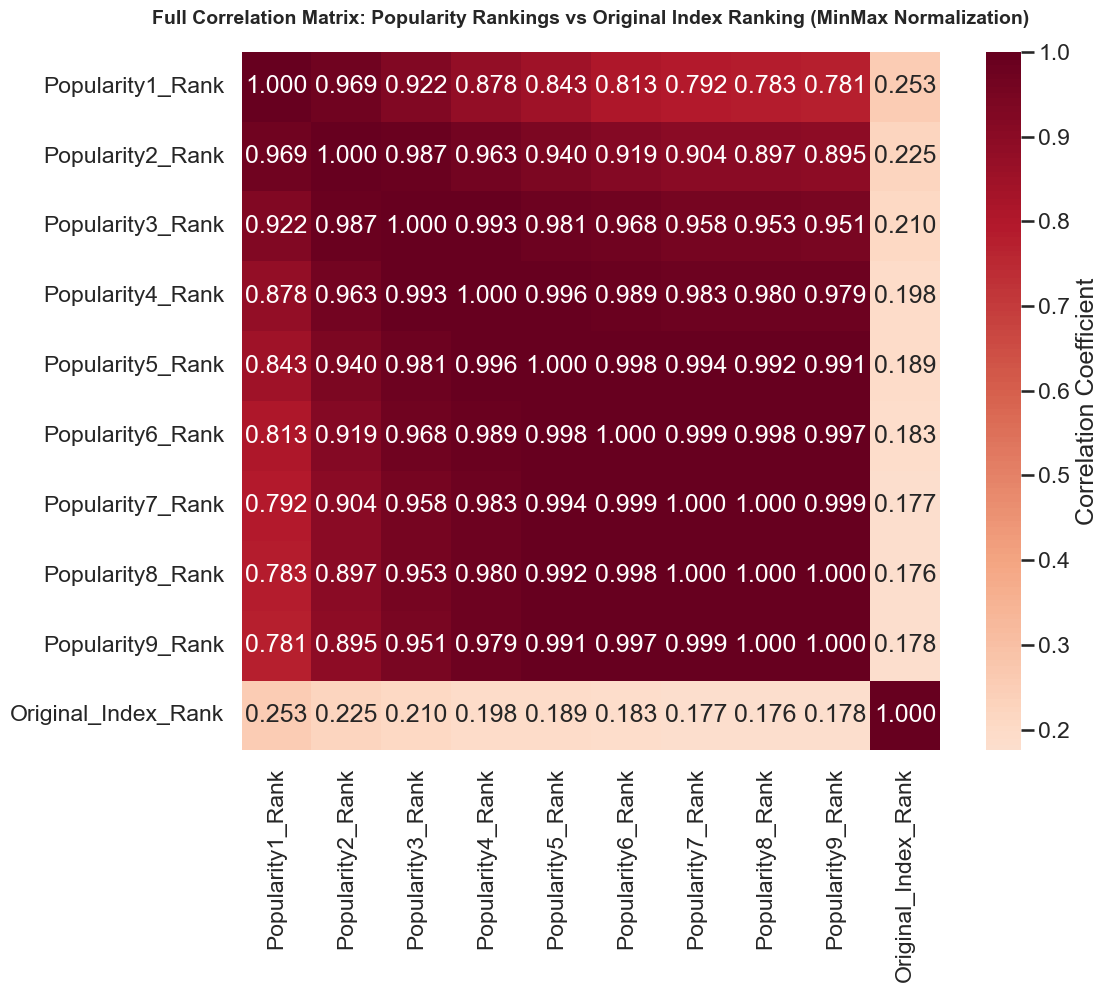

In [17]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()  
scraped_data['EndTime_norm'] = scaler.fit_transform(scraped_data[['End_date']])  

coefficient_sets = [
    (0.9, 0.1),  
    (0.8, 0.2),
    (0.7, 0.3),
    (0.6, 0.4),
    (0.5, 0.5),   
    (0.4, 0.6),
    (0.3, 0.7),
    (0.2, 0.8),
    (0.1, 0.9),   
]

popularity_columns = []
for i, (alpha, beta) in enumerate(coefficient_sets, 1):
    col_name = f'Popularity{i}'
    scraped_data[col_name] = (
        alpha * scraped_data['Rating'] + 
        beta * scraped_data['Show_duration'] * scraped_data['EndTime_norm']
    )
    popularity_columns.append(col_name)

rank_columns = []
for pop_col in popularity_columns:
    rank_col = f'{pop_col}_Rank'
    scraped_data[rank_col] = scraped_data[pop_col].rank(ascending=False, method='min') - 1
    rank_columns.append(rank_col)

scraped_data['Original_Index_Rank'] = range(len(scraped_data))

plt.figure(figsize=(12, 10))
correlation_data = scraped_data[rank_columns + ['Original_Index_Rank']]
correlation_matrix = correlation_data.corr()

sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='RdBu_r', 
            center=0,
            square=True,
            fmt='.3f',
            cbar_kws={'label': 'Correlation Coefficient'})

plt.title('Full Correlation Matrix: Popularity Rankings vs Original Index Ranking (MinMax Normalization)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

norm_correlations = []  
for rank_col in rank_columns:
    corr = scraped_data[rank_col].corr(scraped_data['Original_Index_Rank'])
    norm_correlations.append(corr)

norm_avg_correlation = np.mean(norm_correlations)

The correlation decreases a lot compared to the standardization,which means the end year has a positive result for the final ranking. Because its function is sparse here, which results in a decrease in the correlation. We can now try only rank the data by the ratings. If the result is lower than the first result of our formula, it will support our idea that the ranking is related to the duration, end time and rating.

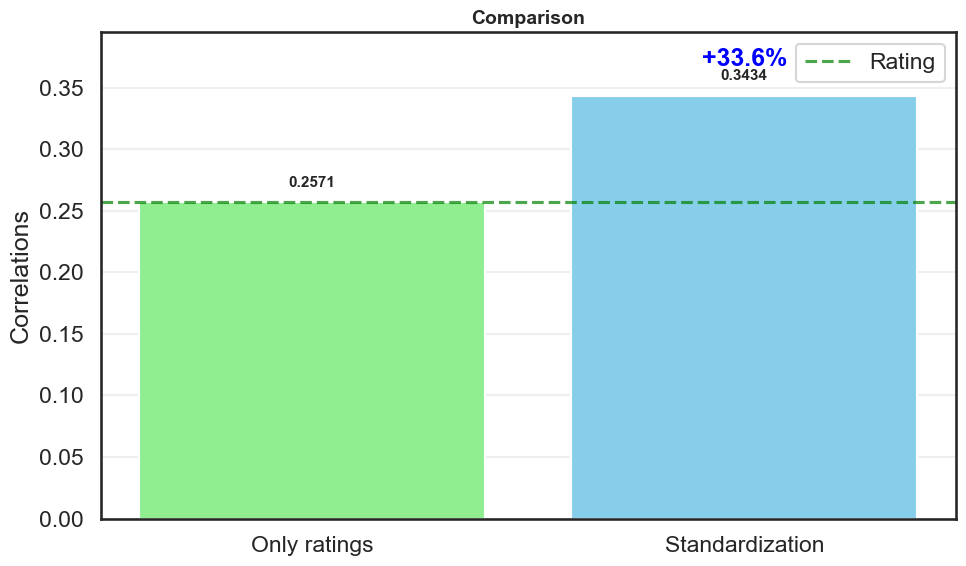

In [18]:
scraped_data['Rating_Rank'] = scraped_data['Rating'].rank(ascending=False, method='min') - 1
rating_correlation = scraped_data['Rating_Rank'].corr(scraped_data['Original_Index_Rank'])
methods = ['Only ratings', 'Standardization']
correlations = [rating_correlation, std_avg_correlation]

plt.figure(figsize=(10, 6))
bars = plt.bar(methods, correlations, color=['lightgreen', 'skyblue'])

plt.axhline(y=rating_correlation, color='green', linestyle='--', alpha=0.7, label='Rating')
plt.grid(True, alpha=0.3, axis='y')

plt.title('Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Correlations')
plt.ylim(0, max(correlations) * 1.15)
for bar, corr in zip(bars, correlations):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, 
             f'{corr:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

rating_improvement_std = (std_avg_correlation - rating_correlation) / rating_correlation * 100

plt.text(1, std_avg_correlation + 0.02, f'+{rating_improvement_std:.1f}%', 
         ha='center', va='bottom', fontweight='bold', color='blue')

plt.legend()
plt.tight_layout()
plt.show()

The figure now proves our point that our formula has a higher correlation than ranking only by ratings. Therefore the ranking is related to duration, end time and rating. The rating plays a greater role here, but the final comprehensive score of the ranking is still related to other factors. After further investigation, the sorting of the website is indeed based on popularity, so the calculation of popularity should be more complex than the formula we hypothesized.

# 2.3 Second hypothesis
We have counted the frequency of occurrence for each genre. We can use bar charts to show the result.

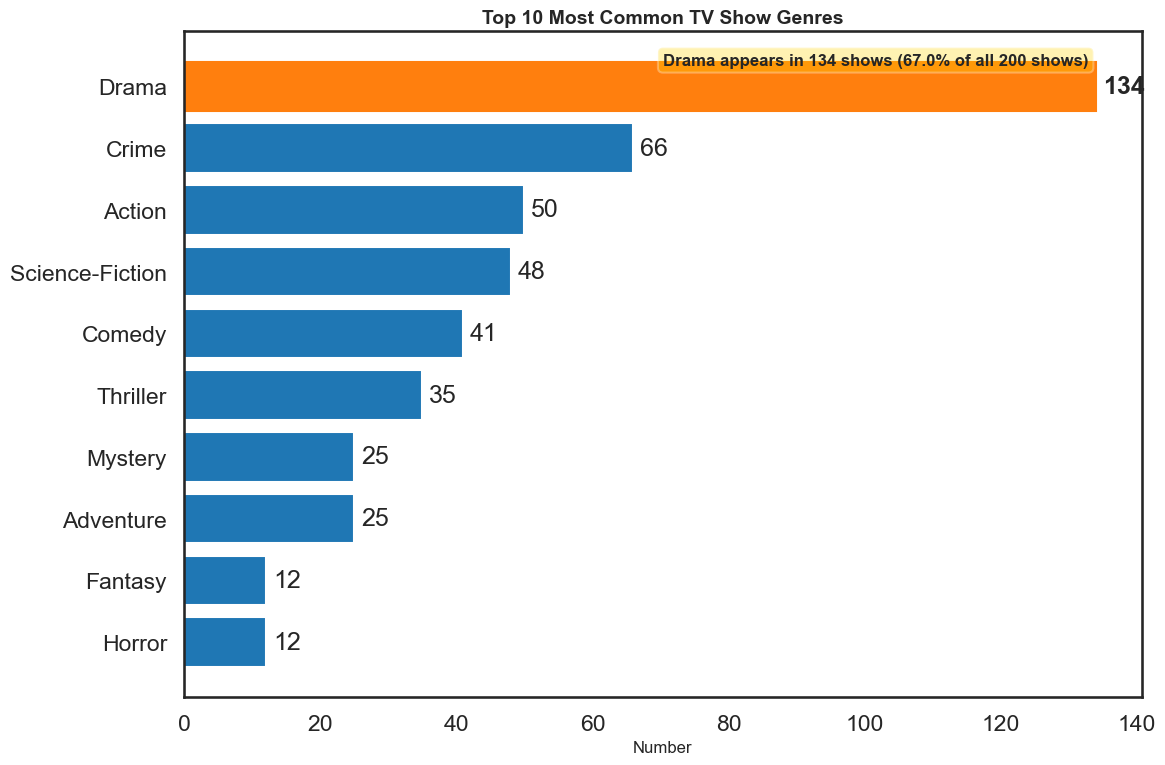

In [19]:
top_10_genres = genre_counts.head(10)

plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(top_10_genres)), top_10_genres.values, 
                color=['#1f77b4' if genre != 'Drama' else '#ff7f0e' for genre in top_10_genres.index])

plt.gca().patches[list(top_10_genres.index).index('Drama')].set_color('#ff7f0e')

plt.yticks(range(len(top_10_genres)), top_10_genres.index)
plt.gca().invert_yaxis()
plt.xlabel('Number', fontsize=12)
plt.title('Top 10 Most Common TV Show Genres', fontsize=14, fontweight='bold')

for i, (genre, count) in enumerate(top_10_genres.items()):
    plt.text(count + 1, i, f'{count}', va='center', fontweight='bold' if genre == 'Drama' else 'normal')

drama_count = genre_counts['Drama']
plt.text(0.5, 0.95, f'Drama appears in {drama_count} shows ({drama_count/len(scraped_data)*100:.1f}% of all 200 shows)', 
         transform=plt.gca().transAxes, fontsize=12, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='gold', alpha=0.3))

plt.tight_layout()
plt.show()

The results are consistent with our hypothesis that drama is the most popular type. Our second hypothesis has been proven. In other words, drama is more likely to be popular.

## 2.4 Third hypothesis
The pie chart is suitable for reflecting market share. But we can also print the result of count the reuslt for the preview.

In [20]:
print(network_counts)

Network_processed
Traditional TV    123
Netflix            19
Apple TV           17
Paramount+         16
Prime Video        14
Disney+             8
HBO Max             2
Now                 1
Name: count, dtype: int64


We can find the values of Disney+, HBO Max and Now are too somall. In order to better present the result, we will merge the parts with a small share into 'other'.

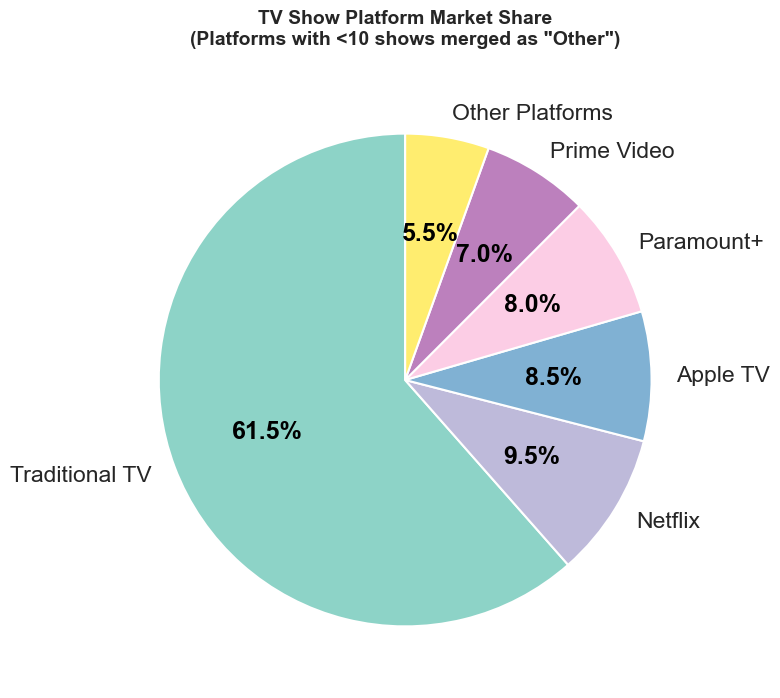

In [21]:
network_counts_filtered = network_counts[network_counts >= 10]
other_count = network_counts[network_counts < 10].sum()

if other_count > 0:
    pie_data = list(network_counts_filtered.values) + [other_count]
    pie_labels = list(network_counts_filtered.index) + ['Other Platforms']
else:
    pie_data = network_counts_filtered.values
    pie_labels = network_counts_filtered.index

plt.figure(figsize=(12, 8))
wedges, texts, autotexts = plt.pie(pie_data, 
                                   labels=pie_labels, 
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   colors=plt.cm.Set3(np.linspace(0, 1, len(pie_data))))

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')

plt.title('TV Show Platform Market Share\n(Platforms with <10 shows merged as "Other")', 
          fontsize=14, fontweight='bold', pad=20)
plt.show()

We can know that traditional television platforms still occupy a large market share. In the remaining market share, Netflix is the majority. The following figure will demonstrate this point.

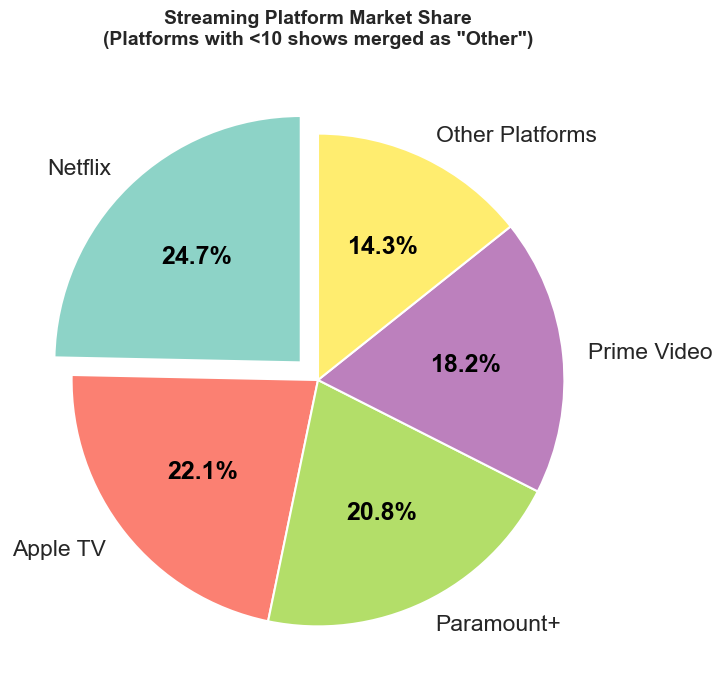

In [22]:
network_filtered = network_counts[network_counts.index != 'Traditional TV']
network_main = network_filtered[network_filtered >= 10]
other_count = network_filtered[network_filtered < 10].sum()

if other_count > 0:
    pie_data = list(network_main.values) + [other_count]
    pie_labels = list(network_main.index) + ['Other Platforms']
else:
    pie_data = network_main.values
    pie_labels = network_main.index

explode = [0.1 if label == 'Netflix' else 0 for label in pie_labels]
plt.figure(figsize=(12, 8))
wedges, texts, autotexts = plt.pie(pie_data, 
                                   labels=pie_labels, 
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   colors=plt.cm.Set3(np.linspace(0, 1, len(pie_data))),
                                   explode=explode)

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')

plt.title('Streaming Platform Market Share\n(Platforms with <10 shows merged as "Other")', 
          fontsize=14, fontweight='bold', pad=20)
plt.show()

Although Netflix is not the majority of the whole market share, it still has the highest share of the streaming platform market. Therefore, our third discovery is that traditional TV still holds the majority of the market share, but Netflix is just behind it.

## 2.5 Summary 
According to our data analysis, we find that the algorith of the sorting is based on the popularity, which is a relatively complex algorithm that is related to duration, end time, and rating. We proposed a relevant formula, but it did not perform well. Following the Popularity line, we continued to explore that the category people like should be drama. We also tried to verify whether Netflix has a large market share, and the results showed that traditional TV is still the majority, but Netflix is the most popular among streaming media.